# Árboles de decisión: regresión

Además de ser útiles para clasificación, los **árboles de decisión** también pueden resolver problemas de **regresión** cuando la variable objetivo es continua. En este caso, el modelo aprende a predecir valores numéricos ajustando particiones en los datos que minimizan el error en cada nodo.

Para realizar la trea de regresión vamos a utilizar la clase [`DecisionTreeRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html#sklearn.tree.DecisionTreeRegressor) de la biblioteca **scikit-learn**. Al igual que `DecisionTreeClassifier` implementa una versión optimizada del algoritmo **CART**, que por el momento no admite variables categóricas.

Trabajaremos con un conjunto de datos que contiene variables clínicas y demográficas de personas con diabetes, con el objetivo de predecir una medida cuantitativa del avance de la enfermedad.

## Librerias

In [1]:
# Análisis exploratorio
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Árboles de desición
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_graphviz
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from graphviz import Source

# Métricas
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, mean_absolute_error,
                             mean_squared_error)
import numpy as np

from sklearn.pipeline import make_pipeline

## Base de datos: diabetes
**Información del conjunto de datos**

Se obtuvieron diez variables basales: edad, sexo, índice de masa corporal, presión arterial promedio y seis mediciones de suero sanguíneo para cada uno de los 442 pacientes con diabetes, así como la respuesta de interés, una medida cuantitativa de la progresión de la enfermedad un año después del inicio.

**Información de variables**

Las primeras 10 columnas (Age, Sex, Body mass index - bmi, Average blood pressure - bp, S1, S2, S3, S4, S5 y S6) son valores numéricos y la columna 11 es una medida cuantitativa de la progresión de la enfermedad un año después del inicio (nuestra variable objetivo).

> **Nota**: Cada una de estas 10 variables se ha centrado en la media y se ha escalado según la desviación estándar multiplicada por `n_muestras`.

In [2]:
!gdown 1H53Qd4cIjqb_aQPftWnTxxNVwH9hIip_

Downloading...
From: https://drive.google.com/uc?id=1H53Qd4cIjqb_aQPftWnTxxNVwH9hIip_
To: /content/diabetes.csv
100% 88.8k/88.8k [00:00<00:00, 32.0MB/s]


In [3]:
df = pd.read_csv('diabetes.csv')

### Estructura
Nombre de variables, variable objetivo, tipos de datos y faltantes.

In [4]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,value
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019908,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068330,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005671,-0.045599,-0.034194,-0.032356,-0.002592,0.002864,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022692,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031991,-0.046641,135.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  value   442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [6]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,value
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-3.629575e-16,1.309912e-16,-8.015207e-16,1.322472e-16,-8.665768e-17,1.321216e-16,-4.558947e-16,3.923458e-16,-3.853127e-16,-3.385929e-16,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123996e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260974e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665645e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324879e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670611e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947634e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564384e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243323e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320442e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335990e-01,1.356118e-01,346.000000


## División train-test

In [7]:
# Separo variable objetivo de datos
X = df.drop('value', axis=1)
y = df['value']

In [8]:
# Obtengo datos de entrenamiento y de testeo
Xtrn, Xtst, ytrn, ytst  = train_test_split(X, y, test_size=0.2,
                            random_state=13, shuffle=True)

## Análisis exploratorio


### Correlación entre variables

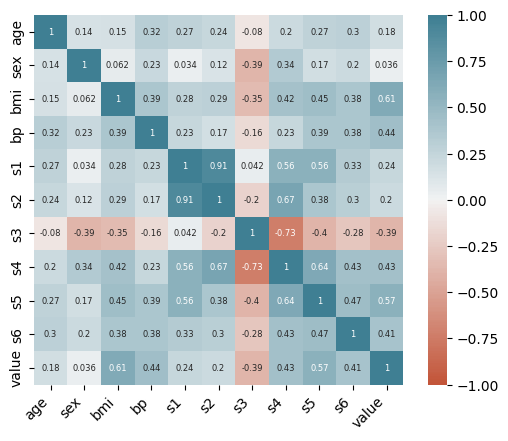

In [9]:
df_trn = pd.concat([Xtrn, ytrn], axis=1)
corr = df_trn.corr(method='pearson')
ax = sns.heatmap(
    corr,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True,
    annot = True,
    annot_kws = {'size': 6}
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
)
plt.show()

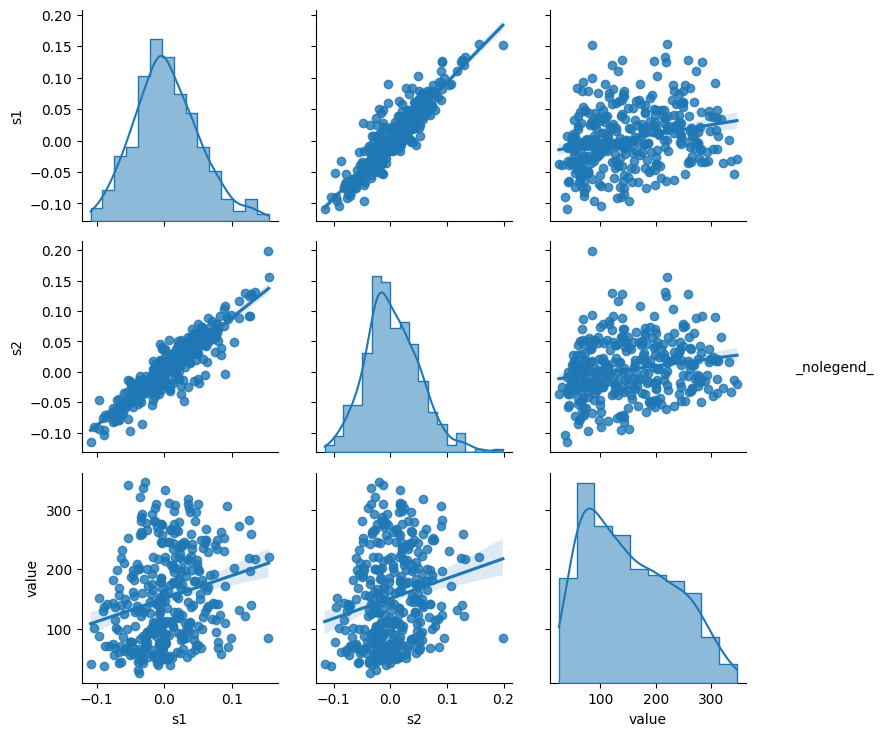

In [10]:
subcols = ['s1', 's2', 'value']
g = sns.PairGrid(df_trn[subcols])
g.map_diag(sns.histplot, kde=True, element='step')
g.map_offdiag(sns.regplot)
g.add_legend()

## Subdivisión en entrenamiento y validación
Para modelos donde es necesario ajustar los hiperparámetros es necesario
separar un subconjunto de validación para probar diferentes
configuraciónes del modelo.

In [11]:
# Obtengo datos de entrenamiento y de testeo
Xtrn, Xval, ytrn, yval  = train_test_split(X, y, test_size=0.2,
                            random_state=13, shuffle=True)

## Selección del modelo

**Parámetros**

Algunos de los parámetros con los que vamos a trabajar en el TP2 son:

`criterion ({“squared_error”, “friedman_mse”, “absolute_error”, “poisson”}, default="squared_error")`

Define una función para medir la calidad de una división. Las opciones incluyen:
* "squared_error": Error medio cuadrático (MSE).
* "friedman_mse": Usa el MSE con la mejora de Friedman.
* "absolute_error": Minimiza el error absoluto medio (MAE).
* "poisson": Usa la reducción de la desviación media de Poisson.

`max_depth (int, default=None)`

Profundidad máxima del árbol. Si no se especifica, el árbol crece hasta que las hojas son puras o contienen menos de min_samples_split muestras.

`min_samples_split (int o float, default=2)`

Número mínimo de muestras necesarias para dividir un nodo interno.

`min_samples_leaf (int o float, default=1)`

Mínimo número de muestras necesarias en un nodo hoja, lo que puede ayudar a suavizar el modelo.

`random_state (int, RandomState instance o None, default=None)`

Controla la aleatoriedad del modelo. Si se fija, se puede obtener un comportamiento determinista.

In [12]:
# Selección del modelo: hiperparámetros
tree_reg = DecisionTreeRegressor(max_depth=3, criterion='squared_error',
                                 min_samples_leaf=1, min_samples_split=2,
                                 random_state=13)
# Entrenamiento
tree_reg.fit(Xtrn, ytrn)

DecisionTreeRegressor(max_depth=3, random_state=13)

### Visualización

In [13]:
# Lista de nombres de las variables
vars_names = list(Xtrn.columns)
print(vars_names)

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


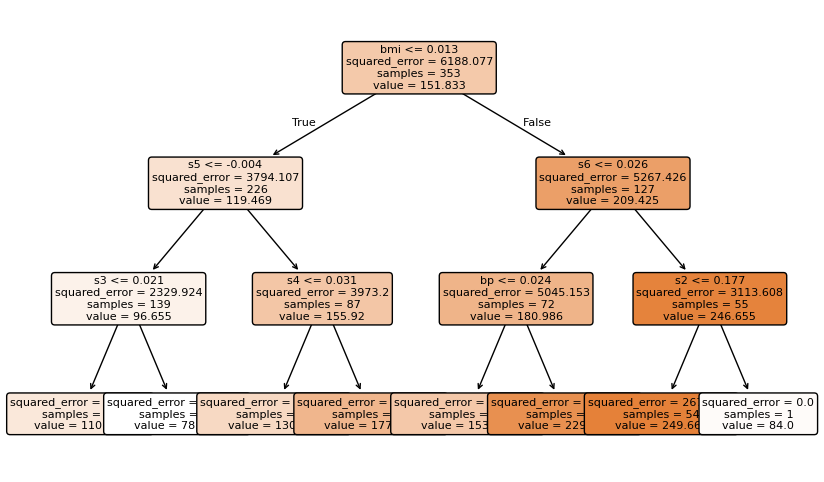

In [14]:
plt.figure(figsize=(10,6))
plot_tree(tree_reg, feature_names=vars_names, fontsize=8, filled=True,
               rounded=True)
plt.show()

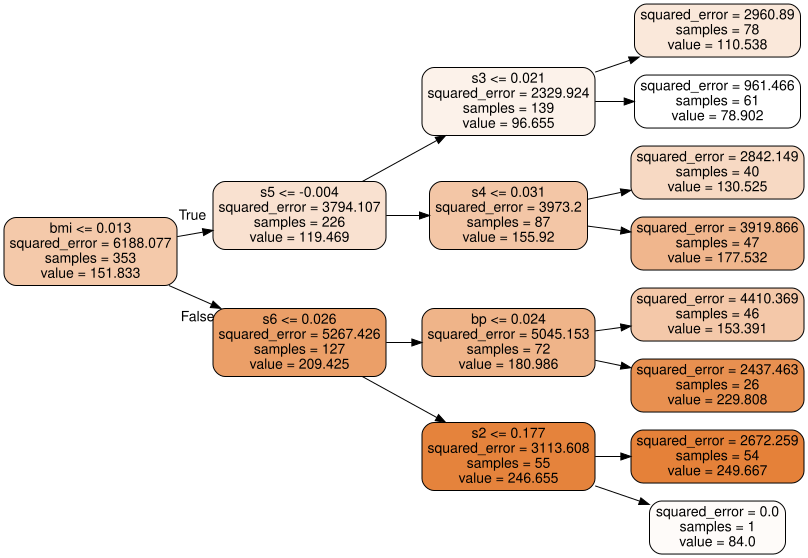

In [15]:
export_graphviz(tree_reg, out_file="diabetes_reg_tree.dot",
                feature_names=vars_names, filled=True, rotate=True, rounded=True)
Source.from_file("diabetes_reg_tree.dot")

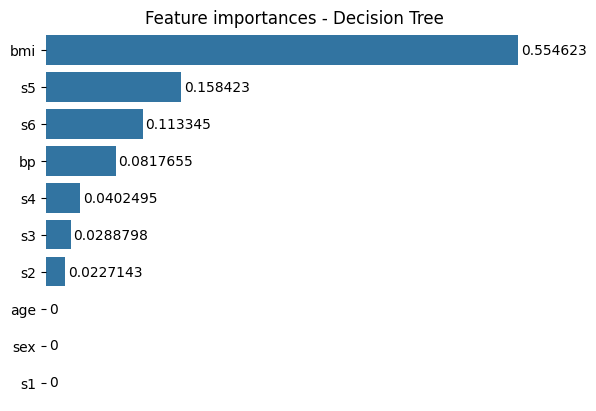

In [16]:
# Creo un df con dos columnas -> Caracteristica y ganacia de información
features_df = pd.DataFrame({'features': vars_names,
                            'importances': tree_reg.feature_importances_ })

# Ordeno en base a la importancia
features_df_sorted = features_df.sort_values(by='importances', ascending=False)

g = sns.barplot(data=features_df_sorted, x='importances', y ='features')
sns.despine(bottom = True, left = True)
g.set_title('Feature importances - Decision Tree')
g.set(xlabel=None, ylabel=None, xticks=[])
for value in g.containers:
    g.bar_label(value, padding=2)

In [17]:
# Predicción en el conjunto de entrenamiento
pred_trn = tree_reg.predict(Xtrn)

# Predicción en el conjunto de validación
pred_val = tree_reg.predict(Xval)

### Calculo de métricas

In [18]:
# primero calculamos el error absoluto porcentual (APE) para cada predicción y
# luego calculamos el MAPE promediando estos errores.
mape = np.mean(np.abs((yval - pred_val) / yval) * 100)

print('Error absoluto medio:', mean_absolute_error(yval, pred_val))
print('Error medio cuadrado:', mean_squared_error(yval, pred_val))
print('Raíz del error medio cuadrado:', np.sqrt(mean_squared_error(yval,
                                                pred_val)))
print("Porcentaje de error medio absoluto (MAPE):", mape)

Error absoluto medio: 46.41047250149773
Error medio cuadrado: 3966.9381624688735
Raíz del error medio cuadrado: 62.983634084330774
Porcentaje de error medio absoluto (MAPE): 35.0592878841974


In [19]:
tableResult = pd.DataFrame({'Actual':yval, 'Predicted':pred_val})
tableResult.head()

,Actual,Predicted
135,272.0,249.666667
358,90.0,78.901639
194,86.0,130.525000
399,232.0,229.807692
405,281.0,229.807692


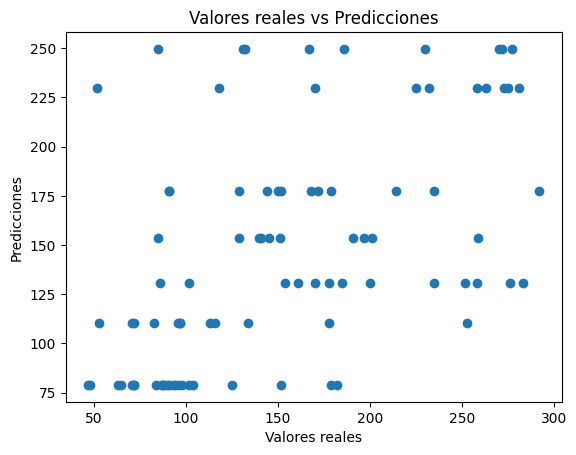

In [20]:
import matplotlib.pyplot as plt
# Graficar valores reales vs predicciones
plt.scatter(ytst, pred_val)
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Valores reales vs Predicciones")
plt.show()